# 06: Lab - Data Scraping

This practice notebook provides additional preparation for Assignment 6. 

## Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`)
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [1]:
#Import packages

#Pandas
import pandas as pd

#Web scraping packages
import requests
from bs4 import BeautifulSoup

#Automation tools
import time
from itertools import product

#Plotting
import seaborn as sns
import matplotlib.pyplot as plt


#Set Seaborn theme
sns.set_theme(    style="whitegrid",
    context= "notebook",
    palette="dark",
    font_scale=0.8,
    rc={
        "xtick.color" : "navy",
        "ytick.color" : "navy"
    }
)

print("SCRAPING IS GOOD FOR DATA COLLECTION ACROSS MULTIPLE PAGES OF THE SAME WEBSITE,")
print("we can set up a script to grab the data and then run the script across multiple pages in the background")
print("")
print("We can do this because most websites use the same html for tables, etc")
print("Sometimes the websites are pretty so we need to use the inspect tool to actually fetch the data and bully an api")

SCRAPING IS GOOD FOR DATA COLLECTION ACROSS MULTIPLE PAGES OF THE SAME WEBSITE,
we can set up a script to grab the data and then run the script across multiple pages in the background

We can do this because most websites use the same html for tables, etc
Sometimes the websites are pretty so we need to use the inspect tool to actually fetch the data and bully an api


## Scraping Exercises

### 1. Scrape 2024 electricity usage data from the EIA 
Let's scrape data the US Energy Administration's State Electricity Archive:
<https://www.eia.gov/electricity/state/>

1. Navigate to the page. Note the year for which these data are provided.
2. Use the Selector Gadget tool to scrape the following values into variables: 
    * State name
    * Average Retail price
    * Net summer capacity
    * Net generation
    * Total retail sales
3. Compile the data into a dataframe
4. Examine the dataframe

**Recall that the BeautifulSoup scraping workflow is as follows**: 
1. Retrieve to the website contents using the `requests.get()` function.
1. Parse the contents into "soup" using BeautifulSoup.
1. Extract specific elements--or *element sets*--in the web site via their node IDs, found using Selector Gadget
    - Convert into lists using list comprehension<br>*Hint:* `[items.get_text(strip=True) for items in the_website.select('<nodeID>')]`
1. Wrangle values into a dataframe
    - Note that scraped values are always returned as strings; you'll need to manually convert these to numeric values (`float` or `int`)
    - Also note that with numbers scraped with a comma separator (e.g. `1,000`), the comma needs to be removed;  `str.replace(',','')` is helpful here
1. Examine the column information for your dataframe.
1. [Optional] Construct a regression plot (`regplot`) showing the relationship of total retail sales to net generation of electricity. 

In [2]:
# 1.1 Fetch and parse the website
url = "https://www.eia.gov/electricity/state/"

response = requests.get(url)
response.raise_for_status()

webpage = BeautifulSoup(response.text, "html.parser")
type(webpage)

if webpage.title: 
    print(webpage.title.get_text(strip=True))
else: print("No page title")

# 1.2 Locate elements and read their text attributes into variables
# trial and error many times with the selector gadget, likely won't get it on first try

#   * state name
States_Nodes = webpage.select("td:nth-child(1)")
States = [node.get_text(strip = True) for node in States_Nodes] #strip or else it leaves the html around the data we want
print("States:",States)

#   * Average Retail price
AvgRetail_Nodes = webpage.select("td:nth-child(2)")
AvgRetail = [node.get_text(strip = True) for node in AvgRetail_Nodes]
print("Average Retail Prices:", AvgRetail)

#   * Net summer capacity
NetSummerCapacity_Nodes = webpage.select("td:nth-child(3)")
NetSummerCapacity = [node.get_text(strip = True) for node in NetSummerCapacity_Nodes]
print("Net Summer Capacity:", NetSummerCapacity)

#   * Net generation

NetGeneration_Nodes = webpage.select("td:nth-child(4)")
NetGeneration = [node.get_text(strip = True) for node in NetGeneration_Nodes]
print("Net Generation:", NetGeneration)

#   * Total retail sales
TotalRetail_Nodes = webpage.select("td:nth-child(5)")
TotalRetail = [node.get_text(strip = True) for node in NetGeneration_Nodes]
print("Total Retail Sales", TotalRetail)
  


US Electricity Profile
		2024 -
		U.S. Energy Information Administration (EIA)
States: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming', 'U.S. Total']
Average Retail Prices: ['11.90', '22.17', '12.74', '9.59', '27.04', '12.07', '24.37', '13.56', '16.88', '12.53', '11.40', '38.00', '9.51', '12.21', '11.38', '9.34', '11.21', '10.07', '8.80', '19.66', '15.04', '23.94', '14.16', '12.35', '10.93', '11.06'

In [3]:
len(States)

52

In [7]:
# 1.3 Construct a dataframe from the values

ElectricityUS = pd.DataFrame({
    "State": States,
    "Average Retail Prices (cents/kWh)": AvgRetail,
    "Net Summer Capacity (MW)": NetSummerCapacity,
    "Net Generation (MWh)": NetGeneration,
    "Total Retail Sales (MWh)": TotalRetail
})


# 1.4 Wrangle
cols = ["Net Summer Capacity (MW)", "Net Generation (MWh)", "Total Retail Sales (MWh)"]

# use a forloop to make it simpler!!!!
for col in cols:
    ElectricityUS[col] = ElectricityUS[col].str.replace(",", "")
    ElectricityUS[col] = ElectricityUS[col].astype(float)

#also convert avg prices
ElectricityUS["Average Retail Prices (cents/kWh)"] = ElectricityUS["Average Retail Prices (cents/kWh)"].astype(float)


# 1.5 Examine
ElectricityUS.dtypes

# 1.6. Plot

State                                    str
Average Retail Prices (cents/kWh)    float64
Net Summer Capacity (MW)             float64
Net Generation (MWh)                 float64
Total Retail Sales (MWh)             float64
dtype: object

### 2. Repeat, for a different year
* Copy and paste your code in the code chunk below, then modify it to fetch the same data for 2023
    - Note that the URL takes a slightly different format than 2024, but the HTML tags remain the same. 

In [9]:
#Copy and paste code from above; then modify to scrape data for 2023

url = "https://www.eia.gov/electricity/state/archive/2023/"

response = requests.get(url)
response.raise_for_status()

webpage = BeautifulSoup(response.text, "html.parser")
type(webpage)

if webpage.title: 
    print(webpage.title.get_text(strip=True))
else: print("No page title")

# 1.2 Locate elements and read their text attributes into variables
# trial and error many times with the selector gadget, likely won't get it on first try

#   * state name
States_Nodes = webpage.select("td:nth-child(1)")
States = [node.get_text(strip = True) for node in States_Nodes] #strip or else it leaves the html around the data we want
print("States:",States)

#   * Average Retail price
AvgRetail_Nodes = webpage.select("td:nth-child(2)")
AvgRetail = [node.get_text(strip = True) for node in AvgRetail_Nodes]
print("Average Retail Prices:", AvgRetail)

#   * Net summer capacity
NetSummerCapacity_Nodes = webpage.select("td:nth-child(3)")
NetSummerCapacity = [node.get_text(strip = True) for node in NetSummerCapacity_Nodes]
print("Net Summer Capacity:", NetSummerCapacity)

#   * Net generation

NetGeneration_Nodes = webpage.select("td:nth-child(4)")
NetGeneration = [node.get_text(strip = True) for node in NetGeneration_Nodes]
print("Net Generation:", NetGeneration)

#   * Total retail sales
TotalRetail_Nodes = webpage.select("td:nth-child(5)")
TotalRetail = [node.get_text(strip = True) for node in NetGeneration_Nodes]
print("Total Retail Sales", TotalRetail)

ElectricityUS = pd.DataFrame({
    "State": States,
    "Average Retail Prices (cents/kWh)": AvgRetail,
    "Net Summer Capacity (MW)": NetSummerCapacity,
    "Net Generation (MWh)": NetGeneration,
    "Total Retail Sales (MWh)": TotalRetail
})


# 1.4 Wrangle
cols = ["Net Summer Capacity (MW)", "Net Generation (MWh)", "Total Retail Sales (MWh)"]

# use a forloop to make it simpler!!!!
for col in cols:
    ElectricityUS[col] = ElectricityUS[col].str.replace(",", "")
    ElectricityUS[col] = ElectricityUS[col].astype(float)

#also convert avg prices
ElectricityUS["Average Retail Prices (cents/kWh)"] = ElectricityUS["Average Retail Prices (cents/kWh)"].astype(float)


# 1.5 Examine
ElectricityUS


US Electricity Profile
		2023 -
		U.S. Energy Information Administration (EIA)
States: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming', 'U.S. Total']
Average Retail Prices: ['11.47', '21.41', '12.19', '9.73', '24.87', '11.76', '24.24', '12.85', '16.50', '13.53', '11.06', '38.60', '9.08', '11.75', '11.49', '9.42', '10.80', '9.96', '8.91', '20.84', '14.34', '23.21', '13.68', '12.21', '10.95', '10.87',

,State,Average Retail Prices (cents/kWh),Net Summer Capacity (MW),Net Generation (MWh),Total Retail Sales (MWh)
0,Alabama,11.47,31097.0,1.394350e+08,1.394350e+08
1,Alaska,21.41,2821.0,6.717825e+06,6.717825e+06
2,Arizona,12.19,29885.0,1.118387e+08,1.118387e+08
3,Arkansas,9.73,15062.0,6.319565e+07,6.319565e+07
4,California,24.87,90375.0,2.166288e+08,2.166288e+08
5,Colorado,11.76,19541.0,5.754172e+07,5.754172e+07
6,Connecticut,24.24,9936.0,4.066642e+07,4.066642e+07
7,Delaware,12.85,3296.0,4.772059e+06,4.772059e+06
8,District of Columbia,16.50,52.0,1.718700e+05,1.718700e+05
9,Florida,13.53,68723.0,2.597985e+08,2.597985e+08


### 3. Create a scraping *function* to accept a year as the input
* Note, you'll need to add an `if` statement to check whether the year is 2024 or not as the URL changes for years before 2024
* Add a `year` column to the dataframe, setting its value to the year supplied when the function is called. 

In [24]:
# 3. Create a scrape function
def scrape_it(the_year):

# 3.1 Form the base url based on whether the year is 2024 or not
    if the_year == 2024:
        url = "https://www.eia.gov/electricity/state/"
    else: 
        url = f"https://www.eia.gov/electricity/state/archive/{the_year}/"

# 3.2 Fetch & parse the website
    response = requests.get(url)
    response.raise_for_status()
    webpage = BeautifulSoup(response.text, "html.parser")

# 3.3 Extract the data to list variables
    States_Nodes = webpage.select("td:nth-child(1)")
    States = [node.get_text(strip = True) for node in States_Nodes] #strip or else it leaves the html around the data we want

    AvgRetail_Nodes = webpage.select("td:nth-child(2)")
    AvgRetail = [node.get_text(strip = True) for node in AvgRetail_Nodes]

    NetSummerCapacity_Nodes = webpage.select("td:nth-child(3)")
    NetSummerCapacity = [node.get_text(strip = True) for node in NetSummerCapacity_Nodes]

    NetGeneration_Nodes = webpage.select("td:nth-child(4)")
    NetGeneration = [node.get_text(strip = True) for node in NetGeneration_Nodes]

    TotalRetail_Nodes = webpage.select("td:nth-child(5)")
    TotalRetail = [node.get_text(strip = True) for node in NetGeneration_Nodes]


# 3.4 Construct a dataframe from the extracted list variables
    df = pd.DataFrame({
        "Year": the_year,
        "State": States,
        "Average Retail Prices (cents/kWh)": AvgRetail,
        "Net Summer Capacity (MW)": NetSummerCapacity,
        "Net Generation (MWh)": NetGeneration,
        "Total Retail Sales (MWh)": TotalRetail
    })

# 3.5 Wrangle as needed
    cols = ["Net Summer Capacity (MW)", "Net Generation (MWh)", "Total Retail Sales (MWh)"]
    for col in cols:
        df[col] = df[col].str.replace(",", "")
        df[col] = df[col].astype(int)
    df["Average Retail Prices (cents/kWh)"] = df["Average Retail Prices (cents/kWh)"].astype(float)

# 3.6 Return the dataframe
    return df

### 4. Use the function to scrape data for 2017

In [25]:
#Use the function to scrape data for 2017
df_2017 = scrape_it(2017)
df_2017.head()

,Year,State,Average Retail Prices (cents/kWh),Net Summer Capacity (MW),Net Generation (MWh),Total Retail Sales (MWh)
0,2017,Alabama,9.83,29725,139964250,139964250
1,2017,Alaska,19.10,2749,6497466,6497466
2,2017,Arizona,10.64,28595,105851721,105851721
3,2017,Arkansas,8.26,14642,60775298,60775298
4,2017,California,16.06,76414,206146392,206146392


### 5. Use the function to scrape data for 2017-2024
* Construct dataframes for each year
* Concatenate the dataframes into a single dataframe
* Plot electricity prices for Virginia, North Carolina, and South Carolina for the span 2017-2024

In [26]:
# 5.1 Extract and concatenate the dataframes
df_range = pd.concat(
    [scrape_it(the_year) for the_year in range(2017,2025)]
)

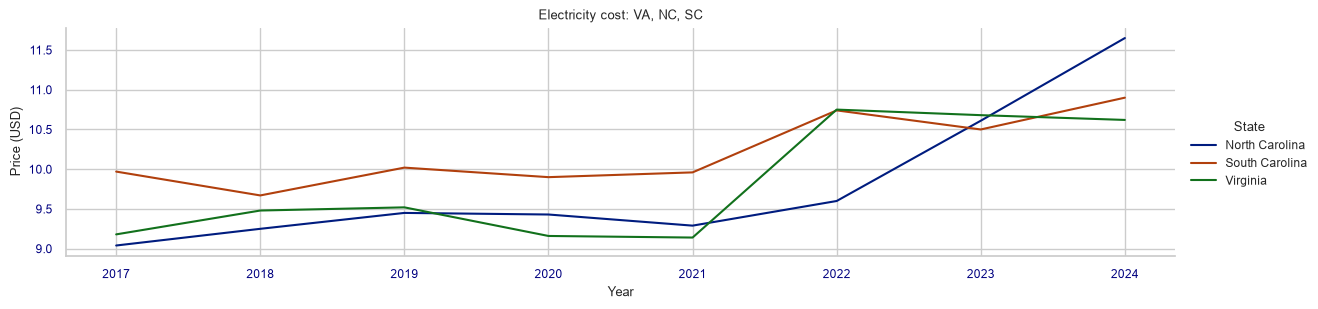

In [28]:
# 5.2 Plot electricity cost for VA, NC, SC
sns.relplot(
    data=df_range[df_range['State'].isin(['Virginia','North Carolina','South Carolina'])],
    x='Year',
    y='Average Retail Prices (cents/kWh)',
    hue='State',
    kind='line',
    height=3,
    aspect=4
).set(
    title='Electricity cost: VA, NC, SC',
    xlabel='Year',
    ylabel='Price (USD)'
);
